# 01 — 시드 데이터 EDA (UnSmile + KOLD)

**목적**
1. 두 시드 데이터셋의 라벨 체계·분포·텍스트 길이를 파악한다.
2. **4단계 위험도 라벨**(`정상/주의/경고/긴급`) 매핑 정책의 근거를 마련한다.
3. `max_length`, 클래스 불균형 가중치, 합성 데이터 우선순위에 대한 의사결정 근거를 만든다.

**D1 산출물**: 본 노트북 + `docs/label_mapping.md` (다음 단계)


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    import koreanize_matplotlib  # noqa: F401
except ImportError:
    plt.rcParams["font.family"] = "AppleGothic"
    plt.rcParams["axes.unicode_minus"] = False

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = ROOT / "data" / "raw"
FIG_DIR = ROOT / "reports" / "figures" / "eda"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
print("ROOT:", ROOT)

ROOT: ~/thisabled-ai


## 1. 데이터 로드


In [2]:
us_tr = pd.read_csv(RAW / "unsmile/unsmile_train_v1.0.tsv", sep="\t")
us_va = pd.read_csv(RAW / "unsmile/unsmile_valid_v1.0.tsv", sep="\t")

with open(RAW / "kold/kold_v1.json", encoding="utf-8") as f:
    kold_raw = json.load(f)
kold = pd.DataFrame(kold_raw)

print(f"UnSmile  train: {len(us_tr):,}  valid: {len(us_va):,}")
print(f"KOLD     total: {len(kold):,}")
print("\nUnSmile columns:", list(us_tr.columns))
print("KOLD    columns:", list(kold.columns))

UnSmile  train: 15,005  valid: 3,737
KOLD     total: 40,429

UnSmile columns: ['문장', '여성/가족', '남성', '성소수자', '인종/국적', '연령', '지역', '종교', '기타 혐오', '악플/욕설', 'clean', '개인지칭']
KOLD    columns: ['guid', 'source', 'date', 'title', 'comment', 'OFF', 'TGT', 'GRP', 'OFF_span', 'TGT_span', 'raw_labels']


## 2. 텍스트 길이 분포 — `max_length` 결정 근거

현재 [configs/module1_kcelectra.yaml](../configs/module1_kcelectra.yaml)의 `max_length=128`.  
KcELECTRA WordPiece는 한국어 텍스트를 보통 **char 수의 ~0.6~0.7배 토큰**으로 쪼갠다 → char p99가 ~150 미만이면 128 안전.


In [3]:
def length_stats(s: pd.Series, name: str) -> dict:
    return {
        "dataset": name,
        "n": len(s),
        "p50": int(s.median()),
        "p90": int(s.quantile(0.9)),
        "p95": int(s.quantile(0.95)),
        "p99": int(s.quantile(0.99)),
        "max": int(s.max()),
    }

lens = pd.DataFrame([
    length_stats(us_tr["문장"].str.len(), "UnSmile train (char)"),
    length_stats(us_va["문장"].str.len(), "UnSmile valid (char)"),
    length_stats(kold["comment"].str.len(), "KOLD comment (char)"),
])
lens

,dataset,n,p50,p90,p95,p99,max
0,UnSmile train (char),15005,31,82,101,137,155
1,UnSmile valid (char),3737,30,82,99,136,149
2,KOLD comment (char),40429,36,99,119,142,203


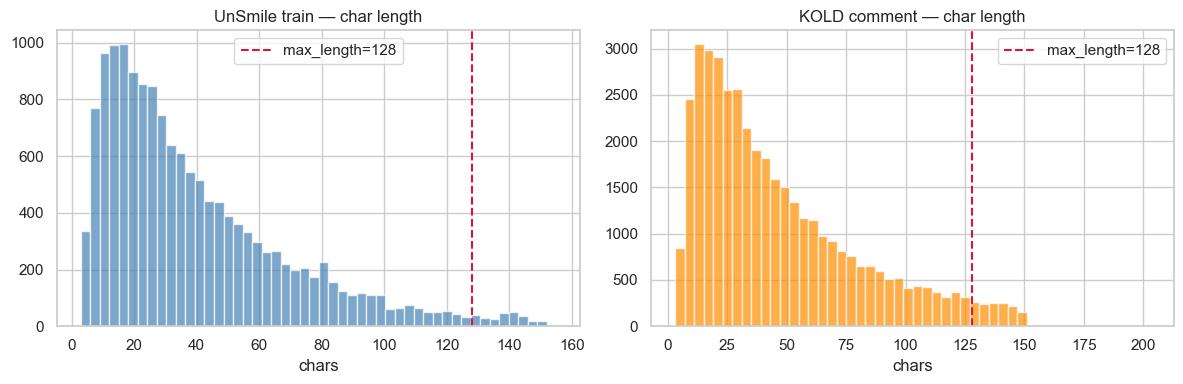

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(us_tr["문장"].str.len(), bins=50, color="steelblue", alpha=0.7)
axes[0].axvline(128, color="crimson", linestyle="--", label="max_length=128")
axes[0].set_title("UnSmile train — char length")
axes[0].set_xlabel("chars")
axes[0].legend()

axes[1].hist(kold["comment"].str.len(), bins=50, color="darkorange", alpha=0.7)
axes[1].axvline(128, color="crimson", linestyle="--", label="max_length=128")
axes[1].set_title("KOLD comment — char length")
axes[1].set_xlabel("chars")
axes[1].legend()

fig.tight_layout()
fig.savefig(FIG_DIR / "text_length.png", dpi=120)
plt.show()

**결론**: 두 데이터 모두 char p99 ≤ 142. WordPiece 변환 후에도 128 토큰 내 → **`max_length=128` 유지**.


## 3. UnSmile 라벨 분포

10개 멀티라벨 (그룹 혐오 7개 + 기타 혐오 + 악플/욕설 + clean) + 개인지칭 indicator.


In [5]:
label_cols = [c for c in us_tr.columns if c != "문장"]
us_label_counts = us_tr[label_cols].sum().sort_values(ascending=False)
us_label_counts

clean    3739
악플/욕설    3143
인종/국적    1728
여성/가족    1599
남성       1347
종교       1181
성소수자     1141
지역       1052
연령        603
기타 혐오     569
개인지칭      315
dtype: int64

/var/folders/qb/jw7rwswx3hjcqwg8s0mytn9w0000gn/T/ipykernel_10566/205261077.py:6: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/qb/jw7rwswx3hjcqwg8s0mytn9w0000gn/T/ipykernel_10566/205261077.py:6: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/qb/jw7rwswx3hjcqwg8s0mytn9w0000gn/T/ipykernel_10566/205261077.py:6: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/qb/jw7rwswx3hjcqwg8s0mytn9w0000gn/T/ipykernel_10566/205261077.py:6: UserWarning: Glyph 52845 (\N{HANGUL SYLLABLE CING}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/qb/jw7rwswx3hjcqwg8s0mytn9w0000gn/T/ipykernel_10566/205261077.py:6: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/qb/jw7rwswx3hjcqwg8s0mytn9w0000gn/T/ipykernel_10566/205261077.py:6: UserWarning: Gly

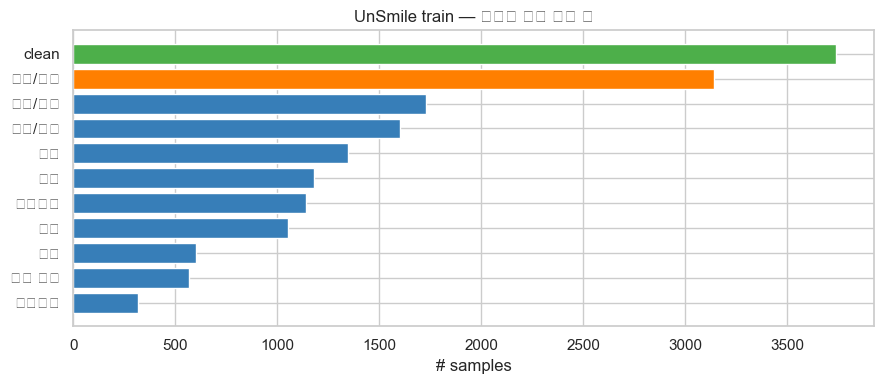

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#4daf4a" if c == "clean" else ("#ff7f00" if c == "악플/욕설" else "#377eb8") for c in us_label_counts.index]
ax.barh(us_label_counts.index[::-1], us_label_counts.values[::-1], color=colors[::-1])
ax.set_title("UnSmile train — 라벨별 양성 샘플 수")
ax.set_xlabel("# samples")
fig.tight_layout()
fig.savefig(FIG_DIR / "unsmile_labels.png", dpi=120)
plt.show()

In [7]:
# 멀티라벨 중첩도 (clean·개인지칭 제외한 "위험" 라벨 9개 기준)
hate_cols = [c for c in label_cols if c not in ("clean", "개인지칭")]
us_tr["n_hate"] = us_tr[hate_cols].sum(axis=1)
n_dist = us_tr["n_hate"].value_counts().sort_index()
print("위험 라벨 양성 개수 분포 (1행당 몇 개의 위험 라벨이 켜져있나):")
print(n_dist.to_string())
print(f"\nclean=1 비율: {(us_tr['clean']==1).mean():.1%}")
print(f"악플/욕설=1 & 그룹혐오=0 (그룹-비특정 욕설): {((us_tr['악플/욕설']==1) & (us_tr[[c for c in hate_cols if c != '악플/욕설']].sum(axis=1)==0)).sum():,}")

위험 라벨 양성 개수 분포 (1행당 몇 개의 위험 라벨이 켜져있나):
n_hate
0     3741
1    10270
2      905
3       76
4       11
5        1
6        1

clean=1 비율: 24.9%
악플/욕설=1 & 그룹혐오=0 (그룹-비특정 욕설): 3,143


## 4. KOLD 라벨 분포


In [8]:
print("OFF (공격성):")
print(kold["OFF"].value_counts().to_string())
print("\nTGT (타겟 유형):")
print(kold["TGT"].value_counts(dropna=False).to_string())
print("\nOFF × TGT 교차표:")
print(pd.crosstab(kold["OFF"], kold["TGT"], margins=True))

OFF (공격성):
OFF
True     20310
False    20119

TGT (타겟 유형):
TGT
None          20119
group         12413
individual     3899
untargeted     2596
other          1402

OFF × TGT 교차표:
TGT   group  individual  other  untargeted    All
OFF                                              
True  12413        3899   1402        2596  20310
All   12413        3899   1402        2596  20310


/var/folders/qb/jw7rwswx3hjcqwg8s0mytn9w0000gn/T/ipykernel_10566/3744719547.py:7: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/qb/jw7rwswx3hjcqwg8s0mytn9w0000gn/T/ipykernel_10566/3744719547.py:7: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/qb/jw7rwswx3hjcqwg8s0mytn9w0000gn/T/ipykernel_10566/3744719547.py:7: UserWarning: Glyph 46608 (\N{HANGUL SYLLABLE DDO}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/qb/jw7rwswx3hjcqwg8s0mytn9w0000gn/T/ipykernel_10566/3744719547.py:7: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/qb/jw7rwswx3hjcqwg8s0mytn9w0000gn/T/ipykernel_10566/3744719547.py:7: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/qb/jw7rwswx3hjcqwg8s0mytn9w0000gn/T/ipykernel_10566/3744719547.py:7: UserWarn

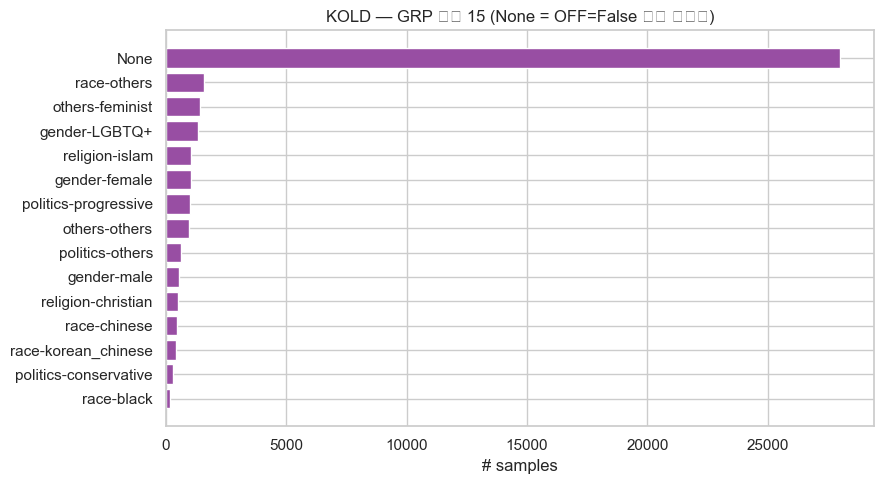

In [9]:
# GRP 상위 카테고리
grp_top = kold["GRP"].value_counts(dropna=False).head(15)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(grp_top.index[::-1].astype(str), grp_top.values[::-1], color="#984ea3")
ax.set_title("KOLD — GRP 상위 15 (None = OFF=False 또는 비타겟)")
ax.set_xlabel("# samples")
fig.tight_layout()
fig.savefig(FIG_DIR / "kold_grp.png", dpi=120)
plt.show()

## 5. 도메인 적합성 — '장애' 키워드 커버리지

본 프로젝트의 도메인은 **장애인 커뮤니티**.  
시드 데이터의 장애 관련 샘플 양이 합성 데이터 필요 규모를 결정한다.


In [10]:
us_dis = us_tr["문장"].str.contains("장애", na=False).sum() + us_va["문장"].str.contains("장애", na=False).sum()
kold_dis_grp = kold["GRP"].astype(str).str.contains("장애", na=False).sum()
kold_dis_txt = kold["comment"].str.contains("장애", na=False).sum()
print(f"UnSmile (train+valid) '장애' 포함: {us_dis:,}")
print(f"KOLD GRP에 '장애' 포함: {kold_dis_grp:,}")
print(f"KOLD comment에 '장애' 포함: {kold_dis_txt:,}")

UnSmile (train+valid) '장애' 포함: 86
KOLD GRP에 '장애' 포함: 0
KOLD comment에 '장애' 포함: 141


## 6. 시드 → 4단계 매핑 정책 (초안)

EDA 결과 기반 매핑 규칙 제안 (`docs/label_mapping.md`로 분리 예정):

| 4단계 | 코드 | UnSmile 규칙 | KOLD 규칙 |
|---|---|---|---|
| **정상** | 0 | `clean == 1` | `OFF == False` |
| **주의** | 1 | `악플/욕설 == 1` AND 그룹 혐오 라벨 모두 0 *(그룹-비특정 욕설)* | `OFF == True` AND `TGT ∈ {individual, untargeted}` |
| **경고** | 2 | 그룹 혐오 라벨 1개 이상 (`여성/가족·남성·성소수자·인종/국적·연령·지역·종교·기타 혐오`) | `OFF == True` AND `TGT == group` |
| **긴급** | 3 | **시드에 거의 없음** → GPT-4o 합성으로 보강 (자해·자살·구체적 위협·심각 폭력) | 동일 |

### 예상 시드 분포 (train+valid, KOLD 전체)

아래 셀로 실측.


In [11]:
def unsmile_to_4class(row: pd.Series) -> int:
    hate = ["여성/가족", "남성", "성소수자", "인종/국적", "연령", "지역", "종교", "기타 혐오"]
    if row["clean"] == 1:
        return 0
    if row[[*hate]].sum() >= 1:
        return 2
    if row["악플/욕설"] == 1:
        return 1
    return 0  # fallback

def kold_to_4class(row: pd.Series) -> int:
    if not row["OFF"]:
        return 0
    if row["TGT"] == "group":
        return 2
    return 1  # individual / untargeted / other

us_all = pd.concat([us_tr, us_va], ignore_index=True)
us_all["label4"] = us_all.apply(unsmile_to_4class, axis=1)
kold["label4"] = kold.apply(kold_to_4class, axis=1)

all_labels = [0, 1, 2, 3]
summary = pd.DataFrame({
    "UnSmile (train+valid)": us_all["label4"].value_counts().reindex(all_labels, fill_value=0),
    "KOLD": kold["label4"].value_counts().reindex(all_labels, fill_value=0),
})
summary.index = ["정상(0)", "주의(1)", "경고(2)", "긴급(3)"]
summary["합계"] = summary.sum(axis=1)
summary["비율"] = (summary["합계"] / summary["합계"].sum() * 100).round(1).astype(str) + "%"
summary

,UnSmile (train+valid),KOLD,합계,비율
정상(0),4676,20119,24795,41.9%
주의(1),3929,7897,11826,20.0%
경고(2),10137,12413,22550,38.1%
긴급(3),0,0,0,0.0%


/var/folders/qb/jw7rwswx3hjcqwg8s0mytn9w0000gn/T/ipykernel_10566/1508638989.py:7: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/qb/jw7rwswx3hjcqwg8s0mytn9w0000gn/T/ipykernel_10566/1508638989.py:7: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/qb/jw7rwswx3hjcqwg8s0mytn9w0000gn/T/ipykernel_10566/1508638989.py:7: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/qb/jw7rwswx3hjcqwg8s0mytn9w0000gn/T/ipykernel_10566/1508638989.py:7: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/qb/jw7rwswx3hjcqwg8s0mytn9w0000gn/T/ipykernel_10566/1508638989.py:7: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) Arial.
  fig.tight_layout()
/var/folders/qb/jw7rwswx3hjcqwg8s0mytn9w0000gn/T/ipykernel_10566/1508638989.py:7: User

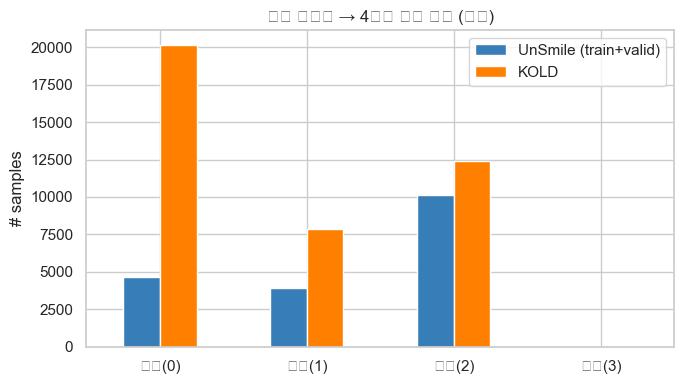

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
summary_plot = summary[["UnSmile (train+valid)", "KOLD"]]
summary_plot.plot(kind="bar", ax=ax, color=["#377eb8", "#ff7f00"])
ax.set_title("시드 데이터 → 4단계 매핑 결과 (초안)")
ax.set_ylabel("# samples")
ax.set_xticklabels(summary.index, rotation=0)
fig.tight_layout()
fig.savefig(FIG_DIR / "label4_distribution.png", dpi=120)
plt.show()

## 7. 핵심 결론 (D1 매핑 정책 결정용)

1. **`max_length=128` 유지** — 두 데이터 모두 char p99 ≤ 142.
2. **긴급(3) 라벨은 시드에 사실상 없음** — GPT-4o 합성 데이터 **필수**. 자해·자살·구체적 위협·심각 폭력 키워드 기반.
3. **클래스 불균형**: 정상 다수, 경고 중간, 주의 적음, 긴급 거의 0 → **Focal Loss + class weight** 설정에서 `alpha` 명시 필요.
4. **장애 도메인 부족**: UnSmile ~86건, KOLD ~141건 → 합성 데이터 생성 시 **장애 관련 페르소나·키워드 비중을 의도적으로 높여야** 한다.
5. **UnSmile 매핑 시 주의**: `악플/욕설=1` & 그룹 혐오=0 인 그룹-비특정 욕설을 **주의(1)** 로 분류. `clean=1` 우선순위 최상위.
6. **KOLD 매핑 시 주의**: `OFF=True` 중 `TGT=other` 처리 정책 확정 필요 (현재 초안은 1로 흡수).

### 다음 단계 (D1 남은 작업)
- [ ] 본 노트북 결론을 `docs/label_mapping.md` 로 분리 정리
- [ ] `src/data/label_mapping.py` 에 위 두 함수 구현 + 단위테스트
- [ ] `src/data/build_dataset.py` 에서 통합 + train/val/test split → `data/processed/*.parquet`
- [ ] `src/training/trainer.py` 골격 작성, 1 epoch 동작 확인
